In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [2]:
data = pd.read_csv("../Datasets/credit_score.csv")
data.head()

,CUST_ID,INCOME,SAVINGS,DEBT,R_SAVINGS_INCOME,R_DEBT_INCOME,R_DEBT_SAVINGS,T_CLOTHING_12,T_CLOTHING_6,R_CLOTHING,...,R_EXPENDITURE_SAVINGS,R_EXPENDITURE_DEBT,CAT_GAMBLING,CAT_DEBT,CAT_CREDIT_CARD,CAT_MORTGAGE,CAT_SAVINGS_ACCOUNT,CAT_DEPENDENTS,CREDIT_SCORE,DEFAULT
0,C02COQEVYU,33269,0,532304,0.0000,16.0000,1.2000,1889,945,0.5003,...,0.0000,0.0625,High,1,0,0,0,0,444,1
1,C02OZKC0ZF,77158,91187,315648,1.1818,4.0909,3.4615,5818,111,0.0191,...,0.7692,0.2222,No,1,0,0,1,0,625,0
2,C03FHP2D0A,30917,21642,534864,0.7000,17.3000,24.7142,1157,860,0.7433,...,1.4286,0.0578,High,1,0,0,1,0,469,1
3,C03PVPPHOY,80657,64526,629125,0.8000,7.8000,9.7499,6857,3686,0.5376,...,1.2500,0.1282,High,1,0,0,1,0,559,0
4,C04J69MUX0,149971,1172498,2399531,7.8182,16.0000,2.0465,1978,322,0.1628,...,0.1163,0.0568,High,1,1,1,1,1,473,0


In [3]:
data.shape

(1000, 87)

In [4]:
data.columns

Index(['CUST_ID', 'INCOME', 'SAVINGS', 'DEBT', 'R_SAVINGS_INCOME',
       'R_DEBT_INCOME', 'R_DEBT_SAVINGS', 'T_CLOTHING_12', 'T_CLOTHING_6',
       'R_CLOTHING', 'R_CLOTHING_INCOME', 'R_CLOTHING_SAVINGS',
       'R_CLOTHING_DEBT', 'T_EDUCATION_12', 'T_EDUCATION_6', 'R_EDUCATION',
       'R_EDUCATION_INCOME', 'R_EDUCATION_SAVINGS', 'R_EDUCATION_DEBT',
       'T_ENTERTAINMENT_12', 'T_ENTERTAINMENT_6', 'R_ENTERTAINMENT',
       'R_ENTERTAINMENT_INCOME', 'R_ENTERTAINMENT_SAVINGS',
       'R_ENTERTAINMENT_DEBT', 'T_FINES_12', 'T_FINES_6', 'R_FINES',
       'R_FINES_INCOME', 'R_FINES_SAVINGS', 'R_FINES_DEBT', 'T_GAMBLING_12',
       'T_GAMBLING_6', 'R_GAMBLING', 'R_GAMBLING_INCOME', 'R_GAMBLING_SAVINGS',
       'R_GAMBLING_DEBT', 'T_GROCERIES_12', 'T_GROCERIES_6', 'R_GROCERIES',
       'R_GROCERIES_INCOME', 'R_GROCERIES_SAVINGS', 'R_GROCERIES_DEBT',
       'T_HEALTH_12', 'T_HEALTH_6', 'R_HEALTH', 'R_HEALTH_INCOME',
       'R_HEALTH_SAVINGS', 'R_HEALTH_DEBT', 'T_HOUSING_12', 'T_HOUSING_6',
 

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 87 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   CUST_ID                  1000 non-null   object 
 1   INCOME                   1000 non-null   int64  
 2   SAVINGS                  1000 non-null   int64  
 3   DEBT                     1000 non-null   int64  
 4   R_SAVINGS_INCOME         1000 non-null   float64
 5   R_DEBT_INCOME            1000 non-null   float64
 6   R_DEBT_SAVINGS           1000 non-null   float64
 7   T_CLOTHING_12            1000 non-null   int64  
 8   T_CLOTHING_6             1000 non-null   int64  
 9   R_CLOTHING               1000 non-null   float64
 10  R_CLOTHING_INCOME        1000 non-null   float64
 11  R_CLOTHING_SAVINGS       1000 non-null   float64
 12  R_CLOTHING_DEBT          1000 non-null   float64
 13  T_EDUCATION_12           1000 non-null   int64  
 14  T_EDUCATION_6            

In [6]:
data.describe()

,INCOME,SAVINGS,DEBT,R_SAVINGS_INCOME,R_DEBT_INCOME,R_DEBT_SAVINGS,T_CLOTHING_12,T_CLOTHING_6,R_CLOTHING,R_CLOTHING_INCOME,...,R_EXPENDITURE_INCOME,R_EXPENDITURE_SAVINGS,R_EXPENDITURE_DEBT,CAT_DEBT,CAT_CREDIT_CARD,CAT_MORTGAGE,CAT_SAVINGS_ACCOUNT,CAT_DEPENDENTS,CREDIT_SCORE,DEFAULT
count,1000.000000,1.000000e+03,1.000000e+03,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,...,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000
mean,121610.019000,4.131896e+05,7.907180e+05,4.063477,6.068449,5.867252,6822.401000,3466.320000,0.454848,0.055557,...,0.943607,0.913340,0.605276,0.944000,0.236000,0.173000,0.993000,0.15000,586.712000,0.284000
std,113716.699591,4.429160e+05,9.817904e+05,3.968097,5.847878,16.788356,7486.225932,5118.942977,0.236036,0.037568,...,0.168989,1.625278,1.299382,0.230037,0.424835,0.378437,0.083414,0.35725,63.413882,0.451162
min,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.003400,...,0.666700,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,300.000000,0.000000
25%,30450.250000,5.971975e+04,5.396675e+04,1.000000,1.454500,0.206200,1084.500000,319.500000,0.263950,0.029700,...,0.833300,0.158700,0.100000,1.000000,0.000000,0.000000,1.000000,0.00000,554.750000,0.000000
50%,85090.000000,2.738505e+05,3.950955e+05,2.545450,4.911550,2.000000,4494.000000,1304.000000,0.468850,0.046800,...,0.909100,0.327950,0.178600,1.000000,0.000000,0.000000,1.000000,0.00000,596.000000,0.000000
75%,181217.500000,6.222600e+05,1.193230e+06,6.307100,8.587475,4.509600,10148.500000,4555.500000,0.626300,0.069400,...,1.000000,0.833300,0.588200,1.000000,0.000000,0.000000,1.000000,0.00000,630.000000,1.000000
max,662094.000000,2.911863e+06,5.968620e+06,16.111200,37.000600,292.842100,43255.000000,39918.000000,1.058300,0.251700,...,2.000200,10.009900,10.005300,1.000000,1.000000,1.000000,1.000000,1.00000,800.000000,1.000000


In [7]:
data.isnull().sum()

CUST_ID                0
INCOME                 0
SAVINGS                0
DEBT                   0
R_SAVINGS_INCOME       0
                      ..
CAT_MORTGAGE           0
CAT_SAVINGS_ACCOUNT    0
CAT_DEPENDENTS         0
CREDIT_SCORE           0
DEFAULT                0
Length: 87, dtype: int64

In [8]:
data.duplicated().sum()

np.int64(0)

In [9]:
data["DEFAULT"].value_counts()

DEFAULT
0    716
1    284
Name: count, dtype: int64

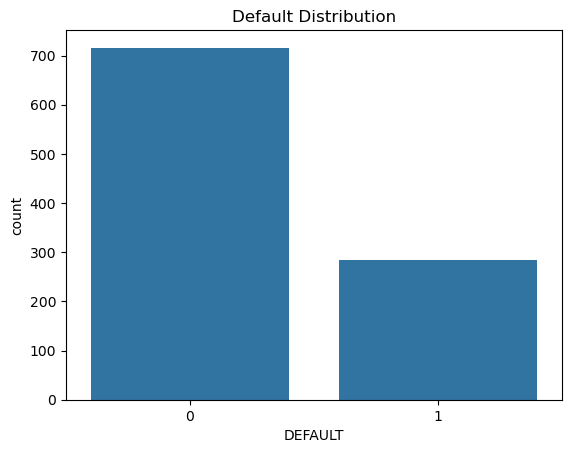

In [10]:
sns.countplot(x=data["DEFAULT"])
plt.title("Default Distribution")
plt.show()

In [11]:
numerical_cols = data.select_dtypes(include=np.number).columns
categorical_cols = data.select_dtypes(include='object').columns

In [12]:
numerical_cols

Index(['INCOME', 'SAVINGS', 'DEBT', 'R_SAVINGS_INCOME', 'R_DEBT_INCOME',
       'R_DEBT_SAVINGS', 'T_CLOTHING_12', 'T_CLOTHING_6', 'R_CLOTHING',
       'R_CLOTHING_INCOME', 'R_CLOTHING_SAVINGS', 'R_CLOTHING_DEBT',
       'T_EDUCATION_12', 'T_EDUCATION_6', 'R_EDUCATION', 'R_EDUCATION_INCOME',
       'R_EDUCATION_SAVINGS', 'R_EDUCATION_DEBT', 'T_ENTERTAINMENT_12',
       'T_ENTERTAINMENT_6', 'R_ENTERTAINMENT', 'R_ENTERTAINMENT_INCOME',
       'R_ENTERTAINMENT_SAVINGS', 'R_ENTERTAINMENT_DEBT', 'T_FINES_12',
       'T_FINES_6', 'R_FINES', 'R_FINES_INCOME', 'R_FINES_SAVINGS',
       'R_FINES_DEBT', 'T_GAMBLING_12', 'T_GAMBLING_6', 'R_GAMBLING',
       'R_GAMBLING_INCOME', 'R_GAMBLING_SAVINGS', 'R_GAMBLING_DEBT',
       'T_GROCERIES_12', 'T_GROCERIES_6', 'R_GROCERIES', 'R_GROCERIES_INCOME',
       'R_GROCERIES_SAVINGS', 'R_GROCERIES_DEBT', 'T_HEALTH_12', 'T_HEALTH_6',
       'R_HEALTH', 'R_HEALTH_INCOME', 'R_HEALTH_SAVINGS', 'R_HEALTH_DEBT',
       'T_HOUSING_12', 'T_HOUSING_6', 'R_HOUSING',

In [13]:
categorical_cols

Index(['CUST_ID', 'CAT_GAMBLING'], dtype='object')

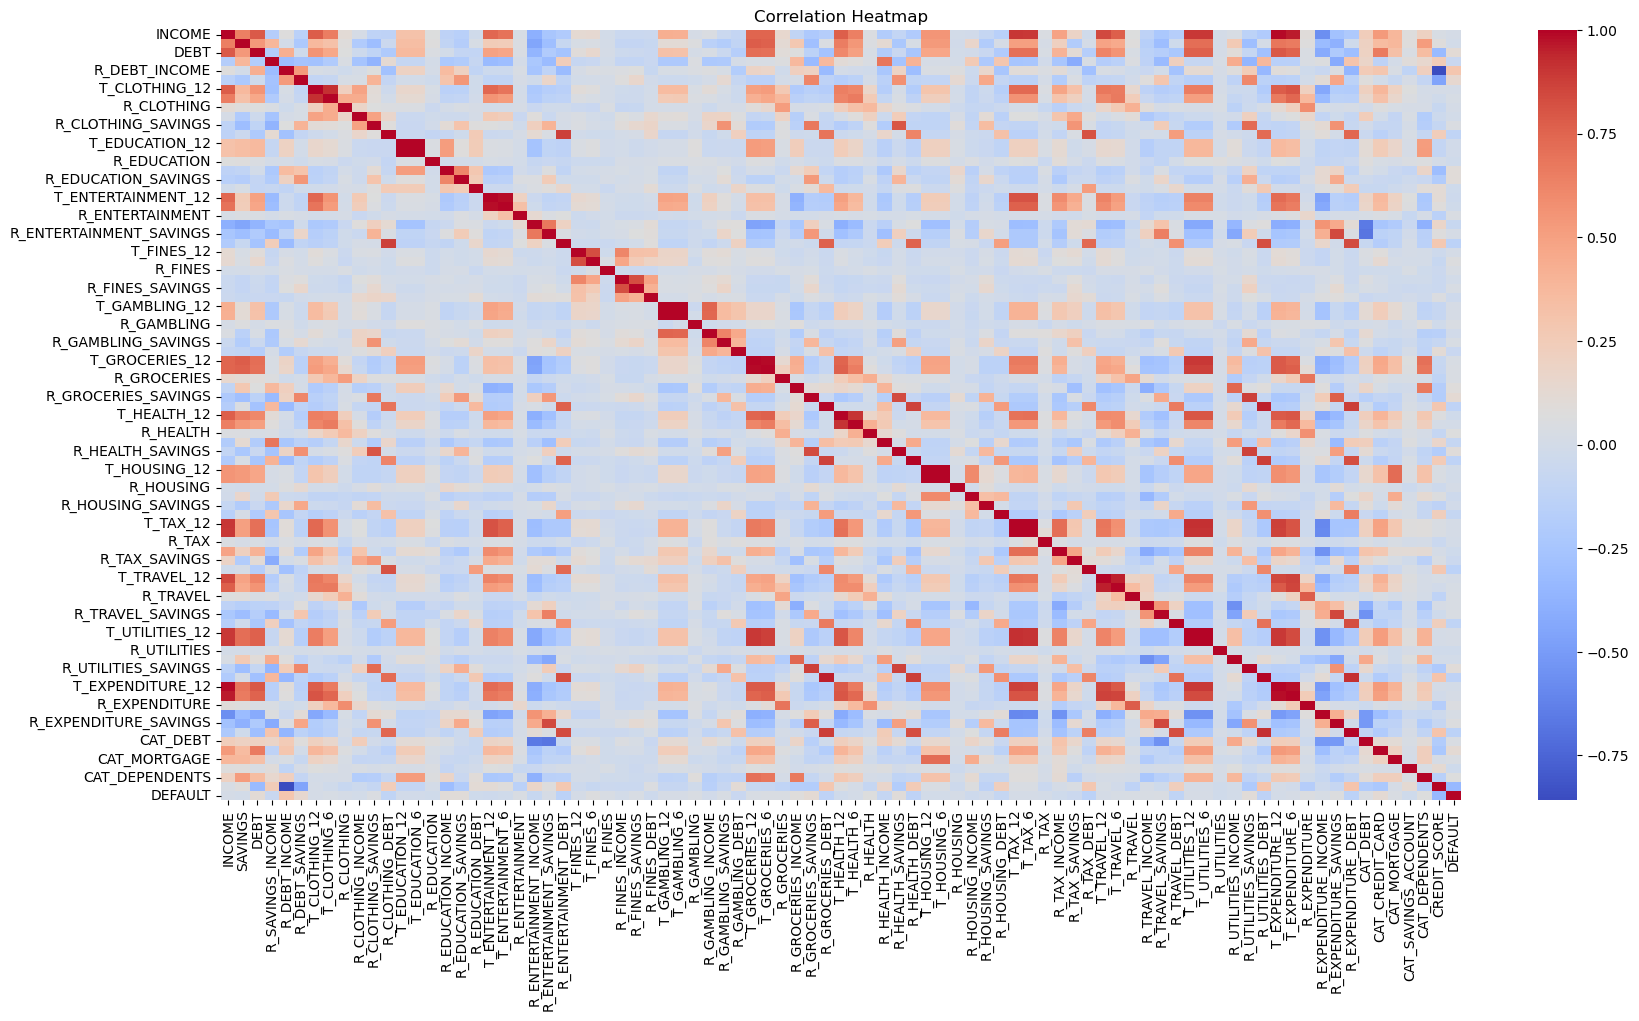

In [14]:
plt.figure(figsize=(20,10))

sns.heatmap(data[numerical_cols].corr(), cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

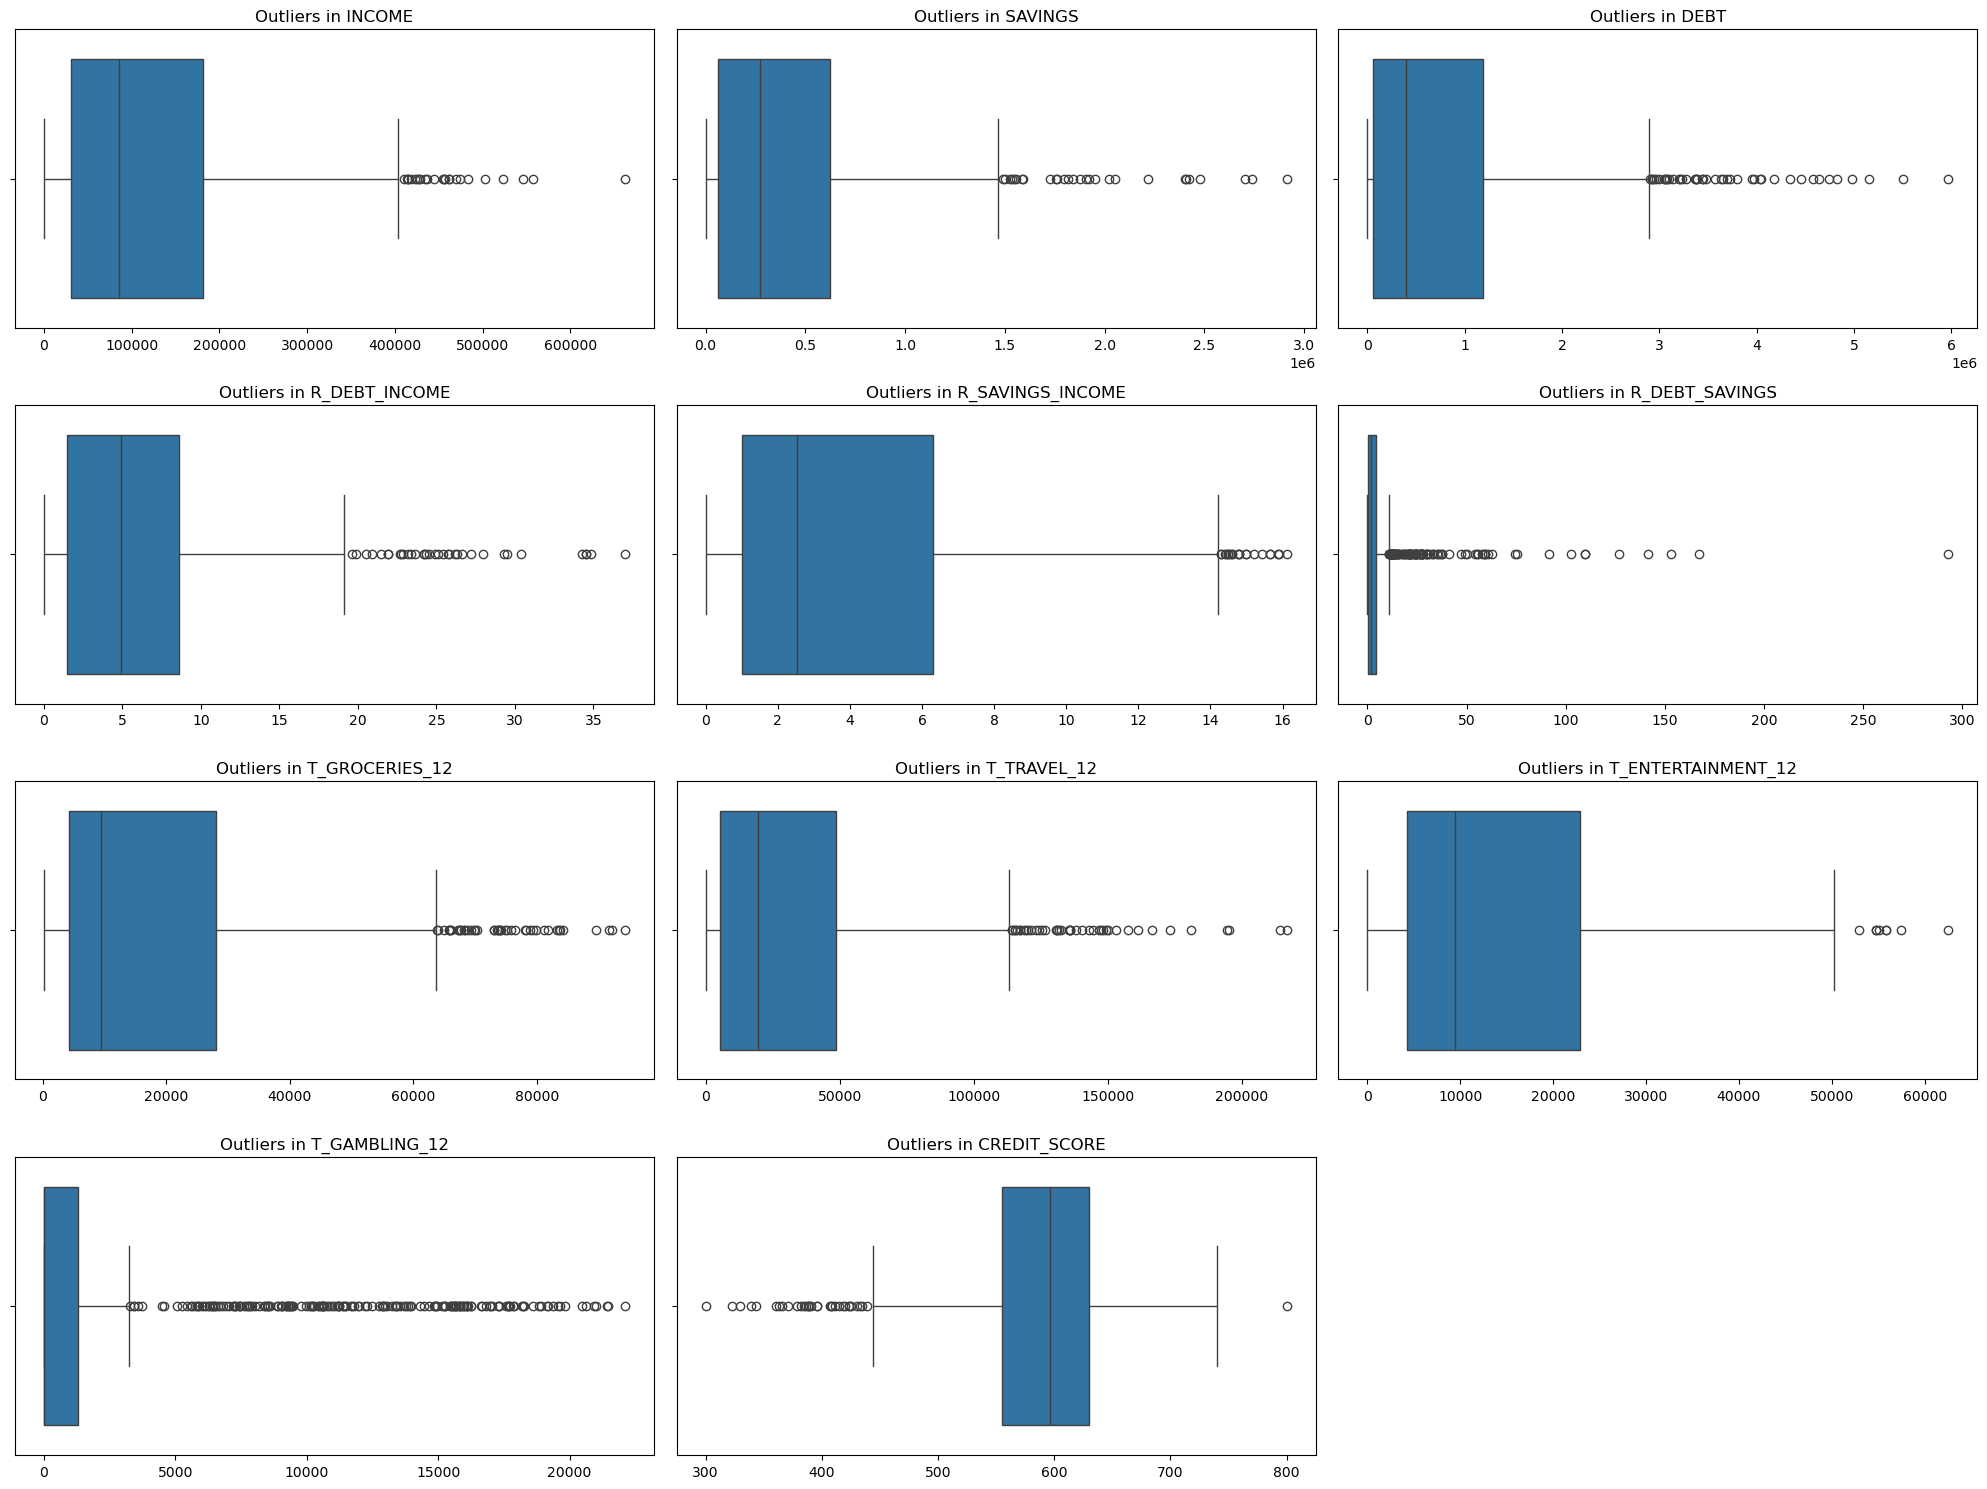

In [15]:
# ================================
# STEP 11 — OUTLIER ANALYSIS
# ================================

# Create large figure
plt.figure(figsize=(20,15))

# Select important numerical columns
important_cols = [
    "INCOME",
    "SAVINGS",
    "DEBT",
    "R_DEBT_INCOME",
    "R_SAVINGS_INCOME",
    "R_DEBT_SAVINGS",
    "T_GROCERIES_12",
    "T_TRAVEL_12",
    "T_ENTERTAINMENT_12",
    "T_GAMBLING_12",
    "CREDIT_SCORE"
]

# Create boxplots
for i, col in enumerate(important_cols):
    
    plt.subplot(4,3,i+1)
    
    sns.boxplot(x=data[col])
    
    plt.title(f"Outliers in {col}")
    
    plt.xlabel("")

# Adjust layout
plt.tight_layout()

# Show plots
plt.show()

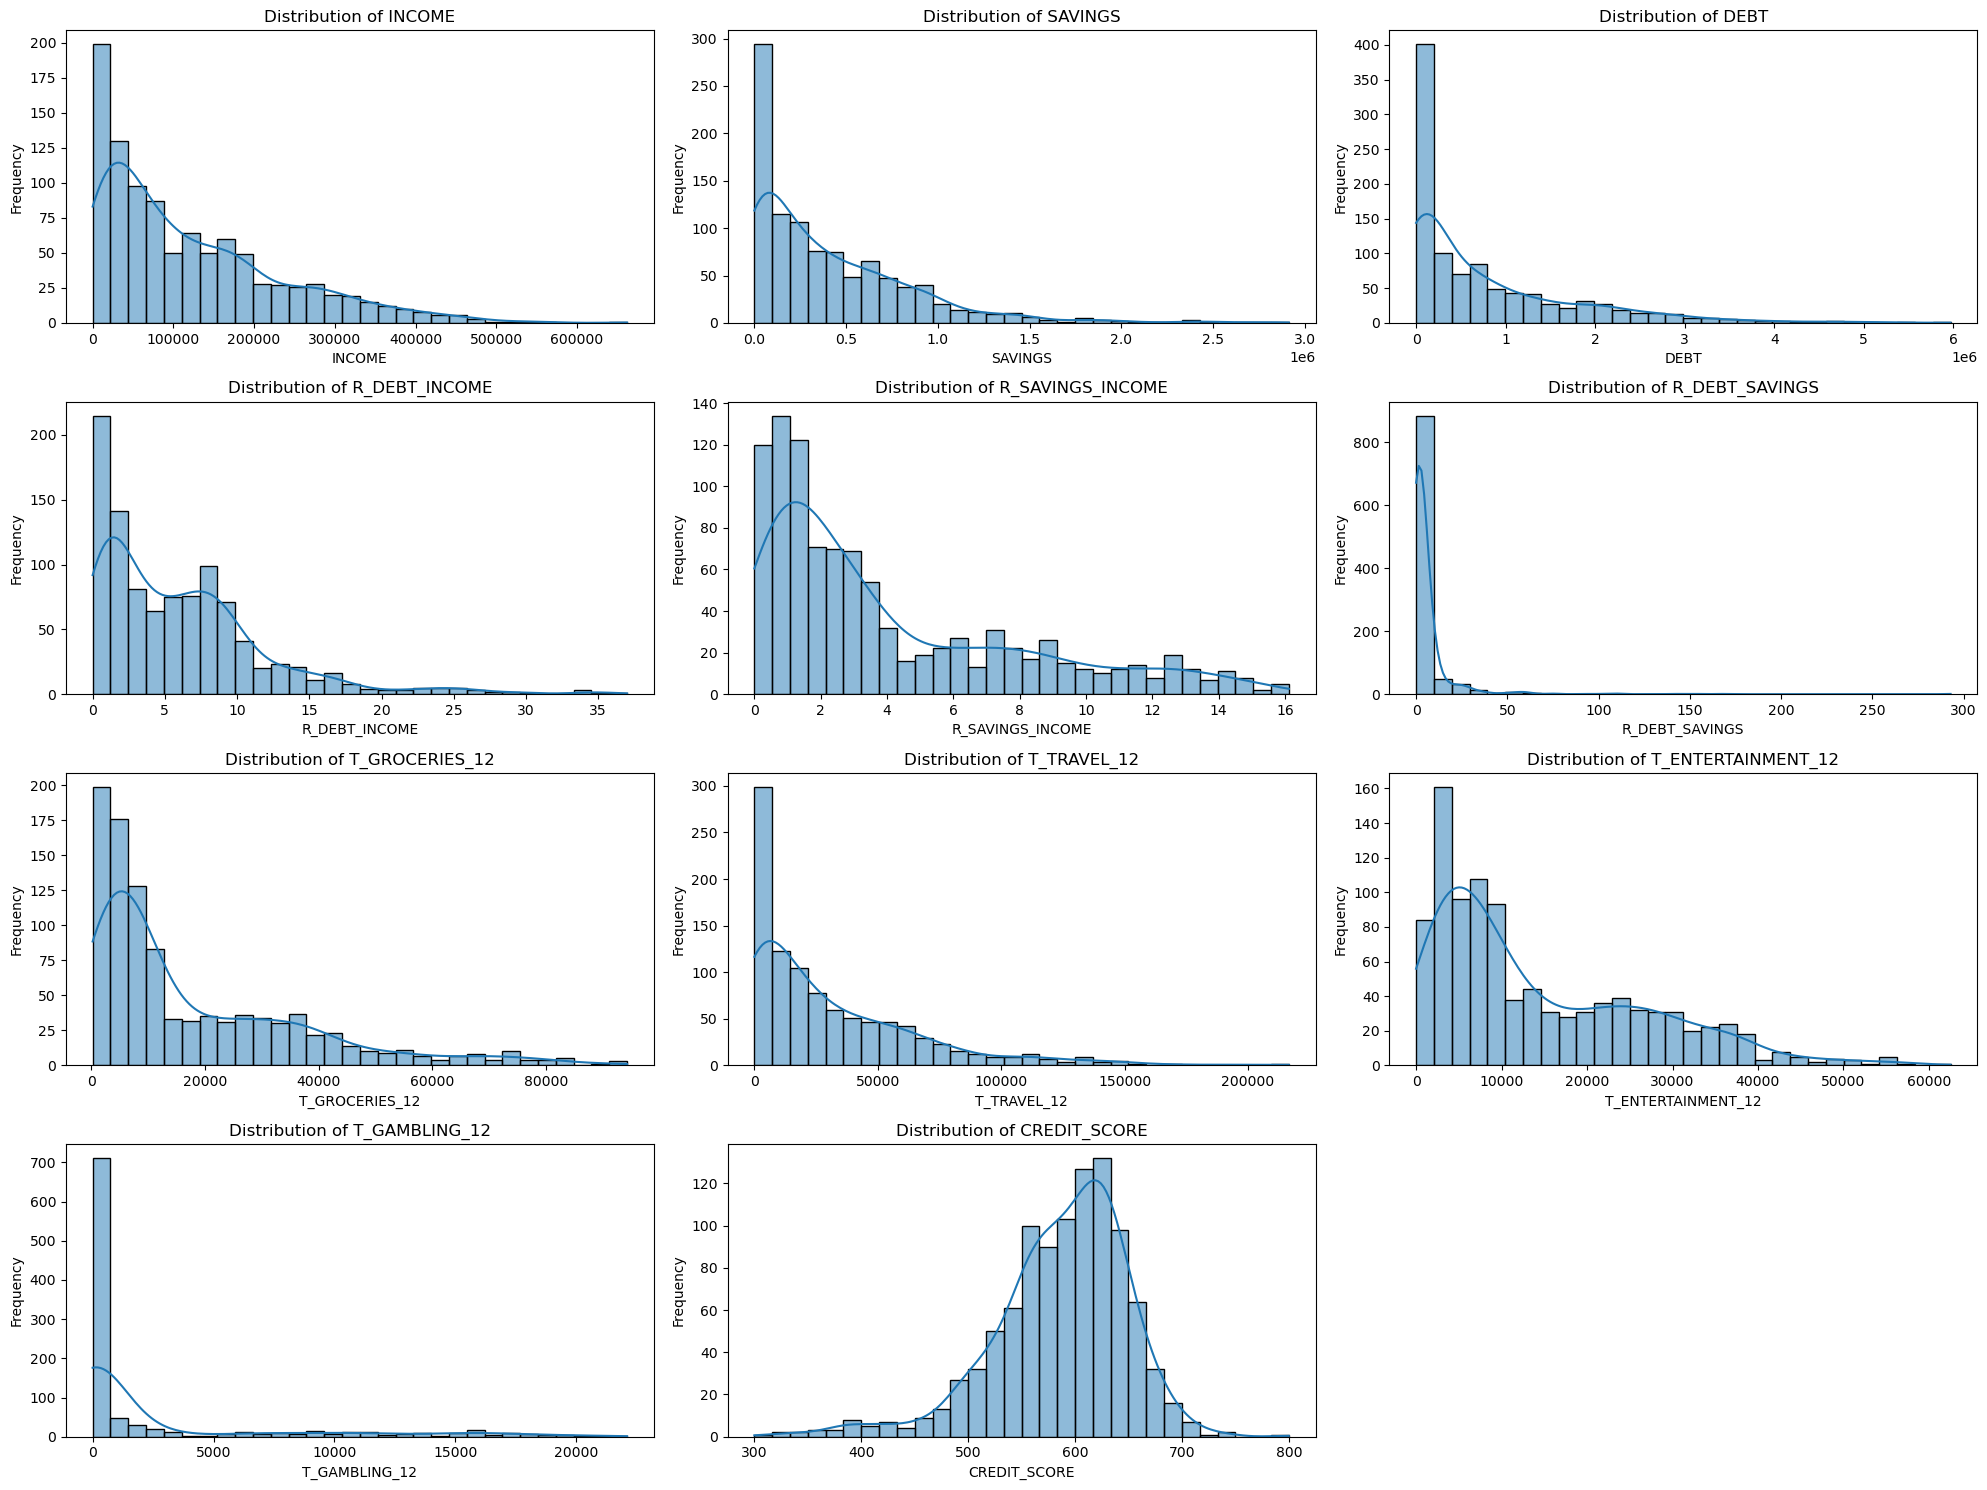

In [16]:
# =====================================
# STEP 12 — DISTRIBUTION ANALYSIS
# =====================================

# Create large figure
plt.figure(figsize=(20,15))

# Important numerical columns
distribution_cols = [
    "INCOME",
    "SAVINGS",
    "DEBT",
    "R_DEBT_INCOME",
    "R_SAVINGS_INCOME",
    "R_DEBT_SAVINGS",
    "T_GROCERIES_12",
    "T_TRAVEL_12",
    "T_ENTERTAINMENT_12",
    "T_GAMBLING_12",
    "CREDIT_SCORE"
]

# Create histograms
for i, col in enumerate(distribution_cols):
    
    plt.subplot(4,3,i+1)
    
    sns.histplot(data[col], bins=30, kde=True)
    
    plt.title(f"Distribution of {col}")
    
    plt.xlabel(col)
    plt.ylabel("Frequency")

# Adjust spacing
plt.tight_layout()

# Show plots
plt.show()

In [19]:
# =====================================
# STEP 13 — FEATURE RELATIONSHIP
# WITH TARGET VARIABLE
# =====================================

# Select only numeric columns
numeric_data = data.select_dtypes(include=np.number)

# Calculate correlation with DEFAULT
correlation_with_target = numeric_data.corr()["DEFAULT"].sort_values(ascending=False)

# Display correlations
print(correlation_with_target)

DEFAULT                 1.000000
R_DEBT_INCOME           0.293035
R_DEBT_SAVINGS          0.136970
CAT_CREDIT_CARD         0.119993
R_GROCERIES_SAVINGS     0.117562
                          ...   
R_UTILITIES_DEBT       -0.130561
R_TAX_DEBT             -0.133679
R_ENTERTAINMENT_DEBT   -0.134185
R_EXPENDITURE_DEBT     -0.139310
CREDIT_SCORE           -0.333092
Name: DEFAULT, Length: 85, dtype: float64


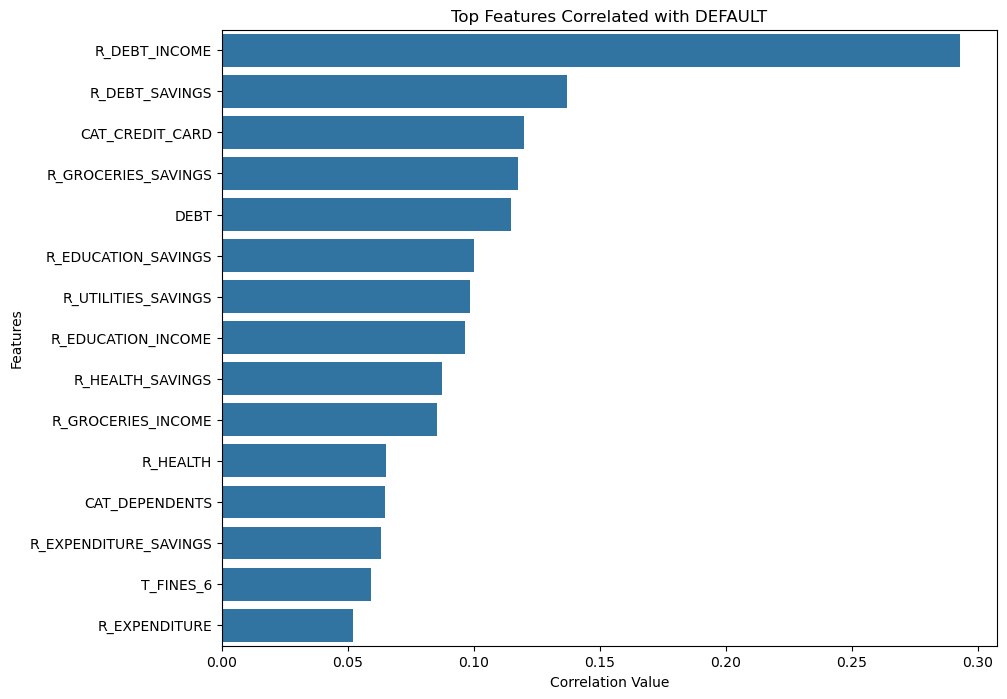

In [20]:
# Select top 15 correlated features
top_features = correlation_with_target[1:16]

# Create graph
plt.figure(figsize=(10,8))

sns.barplot(
    x=top_features.values,
    y=top_features.index
)

plt.title("Top Features Correlated with DEFAULT")

plt.xlabel("Correlation Value")

plt.ylabel("Features")

plt.show()

In [21]:
# =====================================
# STEP 14 — HIGHLY CORRELATED FEATURES
# =====================================

# Create absolute correlation matrix
corr_matrix = numeric_data.corr().abs()

# Create upper triangle matrix
upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

# Find highly correlated features
high_corr_features = [
    column for column in upper_triangle.columns
    if any(upper_triangle[column] > 0.90)
]

# Print highly correlated features
print("Highly Correlated Features:")
print(high_corr_features)

Highly Correlated Features:
['T_CLOTHING_6', 'T_EDUCATION_6', 'T_ENTERTAINMENT_6', 'T_GAMBLING_6', 'T_GROCERIES_6', 'T_HEALTH_6', 'T_HOUSING_6', 'T_TAX_12', 'T_TAX_6', 'T_TRAVEL_6', 'T_UTILITIES_12', 'T_UTILITIES_6', 'R_UTILITIES_DEBT', 'T_EXPENDITURE_12', 'T_EXPENDITURE_6', 'R_EXPENDITURE_DEBT']


In [22]:
# =====================================
# STEP 15 — REMOVE HIGHLY
# CORRELATED FEATURES
# =====================================

# Remove highly correlated features
data = data.drop(columns=high_corr_features)

# Check new dataset shape
print("New Dataset Shape:", data.shape)

New Dataset Shape: (1000, 71)


In [23]:
# Check missing values
missing_values = data.isnull().sum()

# Display columns with missing values
missing_values[missing_values > 0]

Series([], dtype: int64)

In [24]:
# =====================================
# STEP 18 — ENCODE CATEGORICAL FEATURES
# =====================================

from sklearn.preprocessing import LabelEncoder

# Select categorical columns
categorical_cols = data.select_dtypes(include='object').columns

# Initialize encoder
le = LabelEncoder()

# Encode all categorical columns
for col in categorical_cols:
    
    data[col] = le.fit_transform(data[col])

# Check dataset info
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 71 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   CUST_ID                  1000 non-null   int64  
 1   INCOME                   1000 non-null   int64  
 2   SAVINGS                  1000 non-null   int64  
 3   DEBT                     1000 non-null   int64  
 4   R_SAVINGS_INCOME         1000 non-null   float64
 5   R_DEBT_INCOME            1000 non-null   float64
 6   R_DEBT_SAVINGS           1000 non-null   float64
 7   T_CLOTHING_12            1000 non-null   int64  
 8   R_CLOTHING               1000 non-null   float64
 9   R_CLOTHING_INCOME        1000 non-null   float64
 10  R_CLOTHING_SAVINGS       1000 non-null   float64
 11  R_CLOTHING_DEBT          1000 non-null   float64
 12  T_EDUCATION_12           1000 non-null   int64  
 13  R_EDUCATION              1000 non-null   float64
 14  R_EDUCATION_INCOME       

In [25]:
# =====================================
# STEP 20 — FINAL FEATURE PREPARATION
# =====================================

# Remove customer ID
data = data.drop("CUST_ID", axis=1)

# Separate features and target
X = data.drop("DEFAULT", axis=1)

y = data["DEFAULT"]

# Check shapes
print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (1000, 69)
Target Shape: (1000,)


In [26]:
# =====================================
# STEP 21 — FEATURE SCALING
# =====================================

from sklearn.preprocessing import StandardScaler

# Initialize scaler
scaler = StandardScaler()

# Scale features
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame
X_scaled = pd.DataFrame(
    X_scaled,
    columns=X.columns
)

# Display first 5 rows
X_scaled.head()

,INCOME,SAVINGS,DEBT,R_SAVINGS_INCOME,R_DEBT_INCOME,R_DEBT_SAVINGS,T_CLOTHING_12,R_CLOTHING,R_CLOTHING_INCOME,R_CLOTHING_SAVINGS,...,R_EXPENDITURE,R_EXPENDITURE_INCOME,R_EXPENDITURE_SAVINGS,CAT_GAMBLING,CAT_DEBT,CAT_CREDIT_CARD,CAT_MORTGAGE,CAT_SAVINGS_ACCOUNT,CAT_DEPENDENTS,CREDIT_SCORE
0,-0.777240,-0.933351,-0.263339,-1.024549,1.699167,-0.278144,-0.659327,0.192660,0.033098,-0.492067,...,0.842411,0.333879,-0.562241,-1.558246,0.243561,-0.555788,-0.457373,-11.91038,-0.420084,-2.251611
1,-0.391097,-0.727370,-0.484123,-0.726575,-0.338334,-0.143371,-0.134234,-1.847030,0.528442,0.161199,...,-1.939268,-0.204296,-0.088731,0.740052,0.243561,-0.555788,-0.457373,0.08396,-0.420084,0.604082
2,-0.797934,-0.884465,-0.260730,-0.848054,1.921581,1.123182,-0.757155,1.222678,-0.483552,0.055734,...,0.718195,0.333879,0.317187,-1.558246,0.243561,-0.555788,-0.457373,0.08396,-0.420084,-1.857179
3,-0.360312,-0.787594,-0.164673,-0.822840,0.296247,0.231386,0.004624,0.350766,0.784103,0.596368,...,-0.176409,0.333879,0.207243,-1.558246,0.243561,-0.555788,-0.457373,0.08396,-0.420084,-0.437221
4,0.249525,1.715197,1.639472,0.946701,1.699167,-0.227697,-0.647432,-1.237920,-1.128032,-0.474660,...,-0.654451,-0.204296,-0.490648,-1.558246,0.243561,1.799247,2.186400,0.08396,2.380476,-1.794069


In [29]:
# =====================================
# SAVE PROCESSED DATASET
# =====================================

# Save processed dataset
data.to_csv(
    "../Datasets/processed_credit_data.csv",
    index=False
)

print("Processed dataset saved successfully.")

Processed dataset saved successfully.
